# 02 — EDA and Stylized Facts

**What this notebook does**: systematically characterises the statistical properties
of GB electricity prices that our generative model must reproduce.

**Input**: `data/master.parquet` (from notebook 01)

**Output**: `data/stylized_facts.parquet` — a summary table of key statistics,
and `data/returns.parquet` — cleaned arithmetic returns with regime labels

---

## Why stylized facts matter for generative modelling

A generative model that passes the sig-MMD two-sample test (notebook 05) is
statistically indistinguishable from the real data on path space. But the sig-MMD
test is a black box — it tells you *whether* the distributions match, not *where*
they differ if they don't. Stylized facts give us interpretable diagnostics:

1. **Heavy tails** — kurtosis >> 3. Standard Gaussian models fail here.
2. **Volatility clustering** — large moves follow large moves. ACF of |returns| decays slowly.
3. **Seasonality** — diurnal, weekly, and annual patterns in both level and volatility.
4. **Leverage effect** — in equities, price falls → vol increases. In electricity, the
   relationship is more complex: price *spikes* correlate with low wind.
5. **Spike distribution** — rare, large, mean-reverting jumps. Not captured by diffusion models.
6. **Negative prices** — structurally impossible in equity markets, common in electricity.
7. **Wind-price dependence** — the joint distribution of (price, wind) is non-linear
   and regime-dependent.

Each of these will be a validation criterion in notebook 05.

**This notebook uses Polars** for data manipulation (faster than pandas for rolling
windows and group-bys) and matplotlib for plots.


In [ ]:
%pip install -q polars pyarrow matplotlib scipy statsmodels

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/energy_synthetic_data/data


In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from pathlib import Path

PLOT_DIR = DATA_DIR

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Polars version: {pl.__version__}")

Polars version: 1.35.2


In [ ]:
# ── Load master dataset ───────────────────────────────────────────────────────
df = pl.read_parquet(DATA_DIR / "master.parquet")

# Ensure start_time is parsed as datetime
if df["start_time"].dtype == pl.Utf8:
    df = df.with_columns(pl.col("start_time").str.to_datetime())

# Sort by time
df = df.sort("start_time")

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['start_time'].min()} → {df['start_time'].max()}")
print(f"Columns: {df.columns}")

Loaded: 70,129 rows x 86 columns
Date range: 2020-12-31 23:30:00+00:00 → 2024-12-31 23:30:00+00:00
Columns: ['settlement_date', 'settlement_period', 'start_time', 'created_date_time', 'ssp', 'sbp', 'bsad_defaulted', 'price_derivation_code', 'reserve_scarcity_price', 'net_imbalance_volume', 'sell_price_adjustment', 'buy_price_adjustment', 'replacement_price', 'replacement_price_reference_volume', 'total_accepted_offer_volume', 'total_accepted_bid_volume', 'total_adjustment_sell_volume', 'total_adjustment_buy_volume', 'total_system_tagged_accepted_offer_volume', 'total_system_tagged_accepted_bid_volume', 'total_system_tagged_adjustment_sell_volume', 'total_system_tagged_adjustment_buy_volume', 'mid_price', 'biomass', 'ccgt', 'coal', 'intele', 'intelec', 'intew', 'intfr', 'intgrnl', 'intifa2', 'intirl', 'intned', 'intnem', 'intnsl', 'intvkl', 'npshyd', 'nuclear', 'ocgt', 'oil', 'other', 'ps', 'wind', 'total_wind_mw', 'total_renewable_mw', 'total_generation_mw', 'renewable_fraction', 'pct_

---
## 1. Price distribution — heavy tails and spikes

We compute arithmetic returns $r_t = P_t - P_{t-1}$ rather than log returns,
because $\log P_t$ is undefined for negative prices.

For the generative model we will work directly on the price path $P_t$, not
on returns, so the signature will capture the full distributional properties
including the spike and negative price regimes.


In [ ]:
# ── Compute arithmetic returns ────────────────────────────────────────────────
df = df.with_columns([
    pl.col("mid_price").diff().alias("returns"),
    pl.col("mid_price").shift(1).alias("price_lag1"),
])

# Drop the first row (NaN return)
df_ret = df.drop_nulls(subset=["returns"])

returns = df_ret["returns"].to_numpy()
prices  = df_ret["mid_price"].to_numpy()

print("Return statistics:")
print(f"  N:               {len(returns):,}")
print(f"  Mean:            {returns.mean():.4f} £/MWh")
print(f"  Std:             {returns.std():.4f} £/MWh")
print(f"  Skewness:        {stats.skew(returns):.3f}")
print(f"  Excess kurtosis: {stats.kurtosis(returns):.1f}  (Gaussian = 0)")
print(f"  Min:             {returns.min():.1f} £/MWh")
print(f"  Max:             {returns.max():.1f} £/MWh")
print(f"\nPrice statistics:")
print(f"  % negative:      {(prices < 0).mean()*100:.2f}%")
print(f"  % > £500/MWh:    {(prices > 500).mean()*100:.3f}%")
print(f"  % > £1000/MWh:   {(prices > 1000).mean()*100:.3f}%")

Return statistics:
  N:               70,109
  Mean:            -0.0053 £/MWh
  Std:             85.0812 £/MWh
  Skewness:        0.863
  Excess kurtosis: 792.0  (Gaussian = 0)
  Min:             -3950.0 £/MWh
  Max:             3945.0 £/MWh

Price statistics:
  % negative:      3.40%
  % > £500/MWh:    0.793%
  % > £1000/MWh:   0.071%


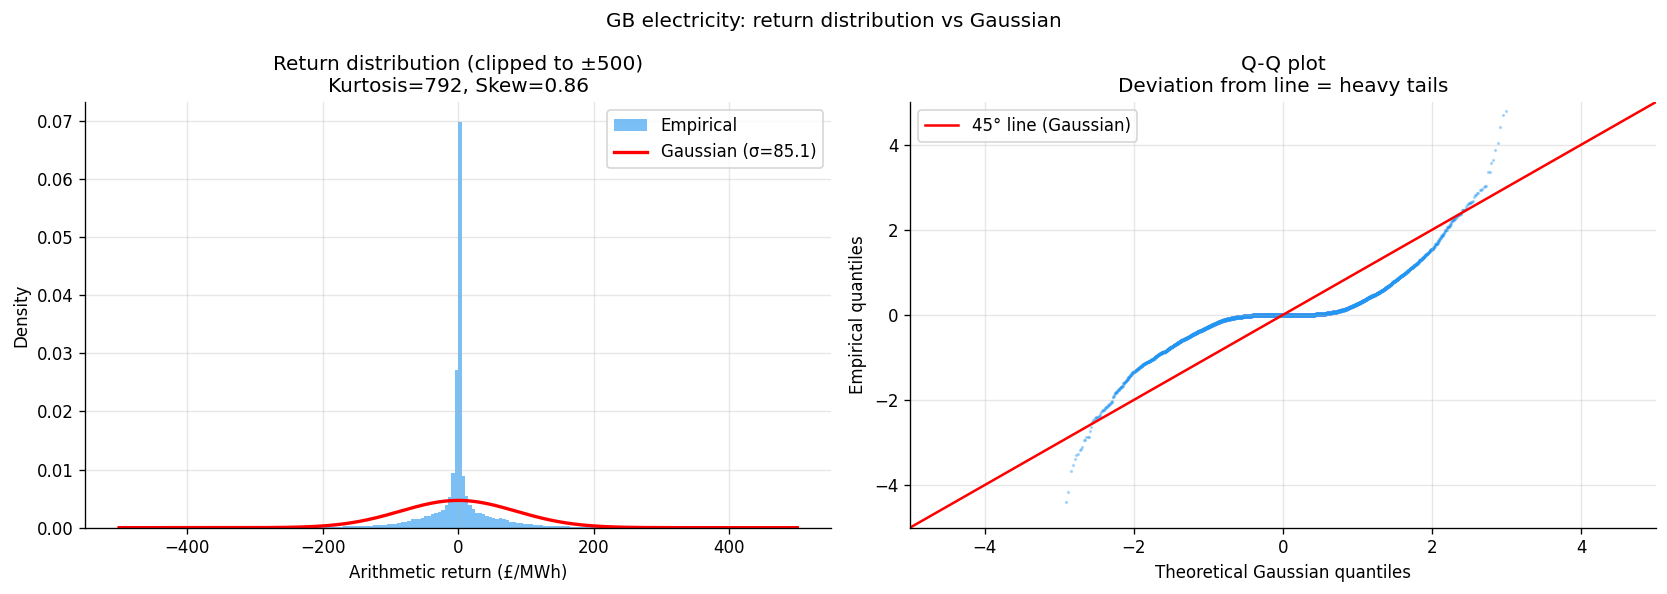

In [ ]:
# ── Plot 1: Return distribution vs Gaussian ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GB electricity: return distribution vs Gaussian", fontsize=12)

# Left: histogram with Gaussian overlay
ax = axes[0]
# Clip for visibility — spikes would compress the histogram
ret_clipped = np.clip(returns, -500, 500)
ax.hist(ret_clipped, bins=200, density=True, alpha=0.6, color="#2196F3", label="Empirical")
x = np.linspace(-500, 500, 500)
ax.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
        "r-", lw=2, label=f"Gaussian (σ={returns.std():.1f})")
ax.set_xlabel("Arithmetic return (£/MWh)")
ax.set_ylabel("Density")
ax.set_title(f"Return distribution (clipped to ±500)\nKurtosis={stats.kurtosis(returns):.0f}, Skew={stats.skew(returns):.2f}")
ax.legend()

# Right: QQ plot
ax = axes[1]
ret_standardised = (returns - returns.mean()) / returns.std()
# Use a sample for speed
sample = np.random.choice(ret_standardised, size=5000, replace=False)
sample.sort()
theoretical = stats.norm.ppf(np.linspace(0.001, 0.999, len(sample)))
ax.scatter(theoretical, sample, alpha=0.3, s=1, color="#2196F3")
ax.plot([-5, 5], [-5, 5], "r-", lw=1.5, label="45° line (Gaussian)")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("Theoretical Gaussian quantiles")
ax.set_ylabel("Empirical quantiles")
ax.set_title("Q-Q plot\nDeviation from line = heavy tails")
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "02a_return_distribution.png", bbox_inches="tight")
plt.show()

---
## 2. Seasonality — diurnal, weekly, and annual patterns

Electricity prices have strong deterministic seasonal components at three frequencies:
- **Diurnal**: morning and evening demand peaks
- **Weekly**: weekday vs weekend demand differences  
- **Annual**: winter heating demand, summer wind troughs

These are conditioning variables in our CVAE — by including Fourier features
for hour and month, the model learns to generate paths appropriate to the
current season rather than averaging over all seasons.


In [ ]:
# ── Add time features ─────────────────────────────────────────────────────────
df = df.with_columns([
    pl.col("start_time").dt.hour().alias("hour"),
    pl.col("start_time").dt.weekday().alias("weekday"),  # 0=Monday
    pl.col("start_time").dt.month().alias("month"),
    pl.col("start_time").dt.year().alias("year"),
])

# Diurnal profile
hourly = (
    df.group_by("hour")
    .agg([
        pl.col("mid_price").mean().alias("mean_price"),
        pl.col("mid_price").std().alias("std_price"),
        pl.col("mid_price").median().alias("median_price"),
    ])
    .sort("hour")
)

# Weekly profile
daily = (
    df.group_by("weekday")
    .agg([
        pl.col("mid_price").mean().alias("mean_price"),
        pl.col("mid_price").std().alias("std_price"),
    ])
    .sort("weekday")
)

# Monthly profile
monthly = (
    df.group_by("month")
    .agg([
        pl.col("mid_price").mean().alias("mean_price"),
        pl.col("mid_price").std().alias("std_price"),
    ])
    .sort("month")
)

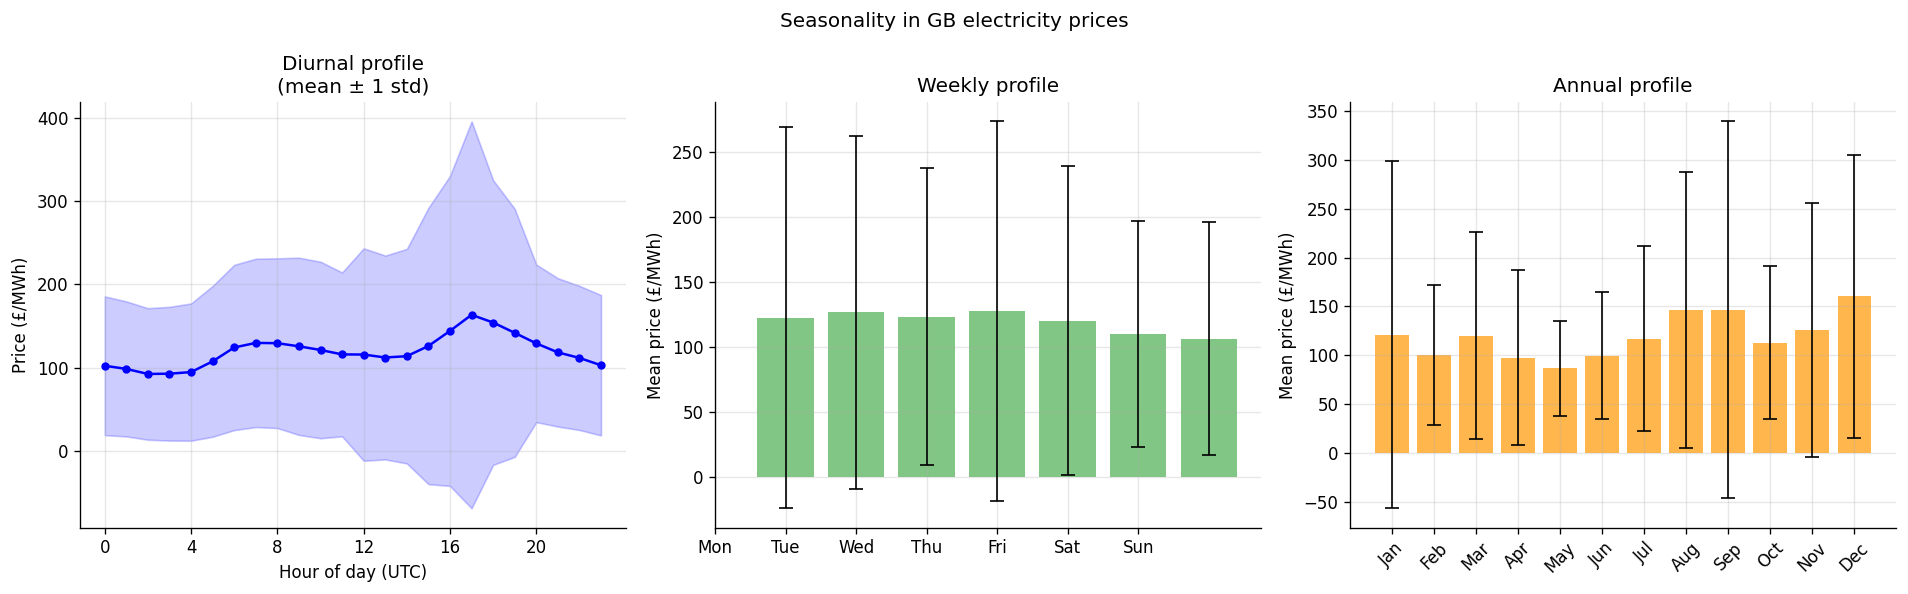

In [ ]:
# ── Plot 2: Seasonal patterns ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Seasonality in GB electricity prices", fontsize=12)

day_names   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Diurnal
ax = axes[0]
h = hourly.to_pandas()
ax.plot(h["hour"], h["mean_price"], "b-o", ms=4, label="Mean")
ax.fill_between(h["hour"],
                h["mean_price"] - h["std_price"],
                h["mean_price"] + h["std_price"],
                alpha=0.2, color="blue")
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Price (£/MWh)")
ax.set_title("Diurnal profile\n(mean ± 1 std)")
ax.set_xticks(range(0, 24, 4))

# Weekly
ax = axes[1]
d = daily.to_pandas()
ax.bar(d["weekday"], d["mean_price"], color="#4CAF50", alpha=0.7)
ax.errorbar(d["weekday"], d["mean_price"], yerr=d["std_price"],
            fmt="none", color="black", capsize=4, lw=1)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.set_ylabel("Mean price (£/MWh)")
ax.set_title("Weekly profile")

# Monthly
ax = axes[2]
m = monthly.to_pandas()
ax.bar(m["month"], m["mean_price"], color="#FF9800", alpha=0.7)
ax.errorbar(m["month"], m["mean_price"], yerr=m["std_price"],
            fmt="none", color="black", capsize=4, lw=1)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.set_ylabel("Mean price (£/MWh)")
ax.set_title("Annual profile")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02b_seasonality.png", bbox_inches="tight")
plt.show()

---
## 3. Autocorrelation — volatility clustering

Two key autocorrelation facts for electricity prices:

1. **Returns are nearly uncorrelated** — $\text{ACF}(r_t) \approx 0$ for most lags
   (prices are hard to predict linearly from past prices)

2. **Absolute returns are strongly autocorrelated** — $\text{ACF}(|r_t|) >> 0$
   and decays slowly. This is volatility clustering: large moves follow large moves.

The slow decay of $\text{ACF}(|r_t|)$ is the empirical signature of GARCH-type
behaviour. Our signature-based generator must capture this because it appears
in the depth-2 signature terms $S^{(1,1)}$ (related to quadratic variation).


In [ ]:
# ── Autocorrelation analysis ──────────────────────────────────────────────────
returns_np = df_ret["returns"].to_numpy()
abs_returns = np.abs(returns_np)
sq_returns  = returns_np ** 2

N_LAGS = 96  # 2 days at half-hourly frequency

acf_returns     = acf(returns_np,  nlags=N_LAGS, fft=True)
acf_abs_returns = acf(abs_returns, nlags=N_LAGS, fft=True)
acf_sq_returns  = acf(sq_returns,  nlags=N_LAGS, fft=True)

# Confidence interval (approximate)
ci = 1.96 / np.sqrt(len(returns_np))

lags = np.arange(N_LAGS + 1)

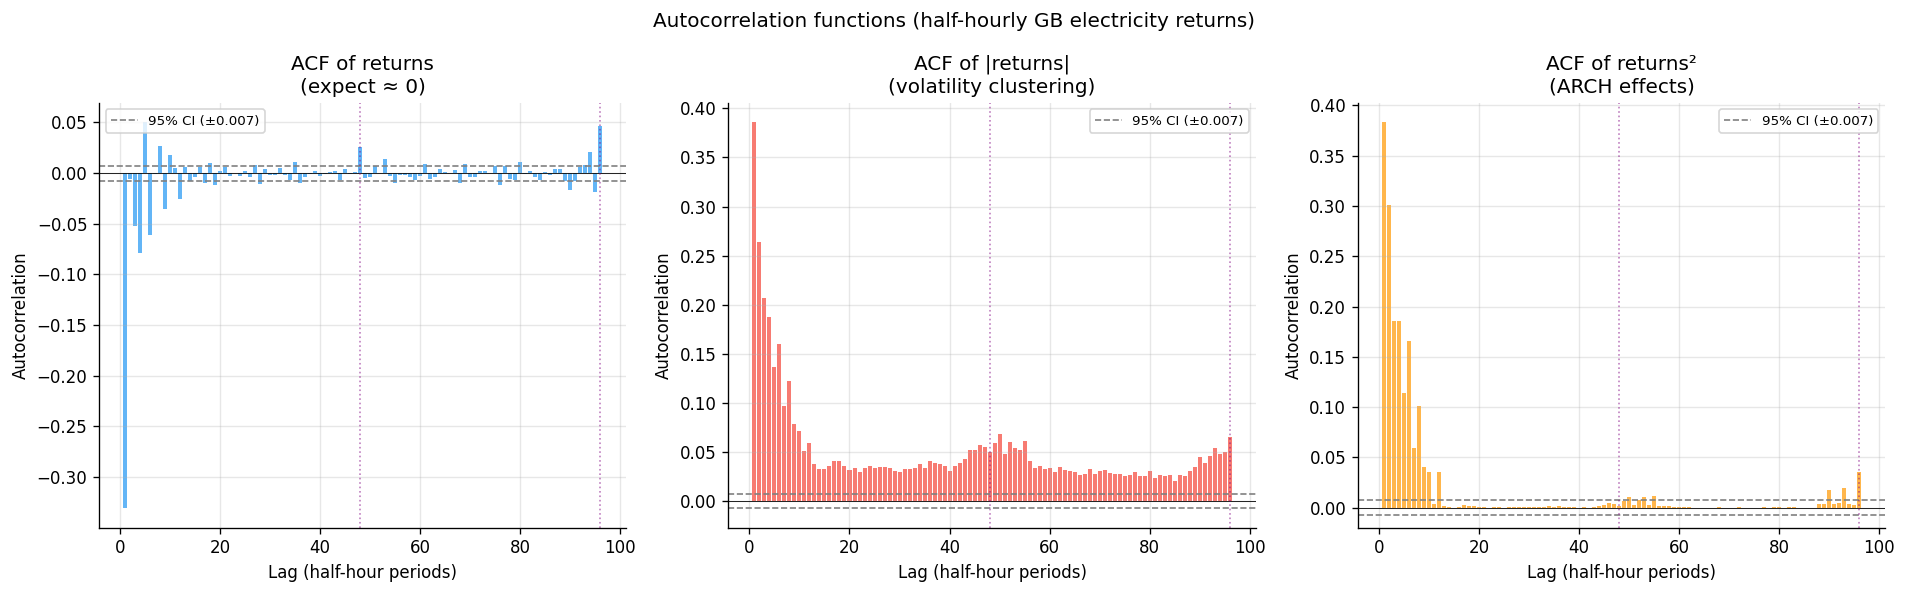

ACF of |returns| at lag 1:  0.386
ACF of |returns| at lag 48: 0.050  (1 day)
ACF of |returns| at lag 96: 0.066  (2 days)


In [ ]:
# ── Plot 3: ACF plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Autocorrelation functions (half-hourly GB electricity returns)", fontsize=12)

for ax, acf_vals, title, color in [
    (axes[0], acf_returns,     "ACF of returns\n(expect ≈ 0)", "#2196F3"),
    (axes[1], acf_abs_returns, "ACF of |returns|\n(volatility clustering)", "#F44336"),
    (axes[2], acf_sq_returns,  "ACF of returns²\n(ARCH effects)", "#FF9800"),
]:
    ax.bar(lags[1:], acf_vals[1:], color=color, alpha=0.7, width=0.8)
    ax.axhline(ci,  color="gray", ls="--", lw=1, label=f"95% CI (±{ci:.3f})")
    ax.axhline(-ci, color="gray", ls="--", lw=1)
    ax.axhline(0,   color="black", lw=0.5)
    ax.set_xlabel("Lag (half-hour periods)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(title)
    ax.legend(fontsize=8)
    # Mark 48-period (1 day) and 96-period (2 day) lags
    for lag in [48, 96]:
        if lag <= N_LAGS:
            ax.axvline(lag, color="purple", ls=":", lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / "02c_autocorrelation.png", bbox_inches="tight")
plt.show()

print(f"ACF of |returns| at lag 1:  {acf_abs_returns[1]:.3f}")
print(f"ACF of |returns| at lag 48: {acf_abs_returns[48]:.3f}  (1 day)")
print(f"ACF of |returns| at lag 96: {acf_abs_returns[96]:.3f}  (2 days)")

---
## 4. Spike analysis

Price spikes in electricity markets are fundamentally different from equity
crashes — they are:
- **Upward** (scarcity events, not crashes)
- **Short-lived** (typically 1-4 half-hour periods before mean reversion)
- **Clustered** in winter and high-demand periods
- **Followed by rapid mean reversion** back to the pre-spike level

We define a spike as any period with price > 3 standard deviations above
the rolling median (more robust than the mean for heavy-tailed distributions).


In [ ]:
# ── Spike identification ──────────────────────────────────────────────────────
# Use a 48-period (1 day) rolling median and MAD for robust spike detection
SPIKE_THRESHOLD_ABS  = 500   # £/MWh — hard threshold
NEGATIVE_THRESHOLD   = 0     # £/MWh

prices_pd = df.select(["start_time", "mid_price"]).to_pandas()
prices_pd = prices_pd.dropna(subset=["mid_price"]).set_index("start_time").sort_index()

# Rolling statistics (48-period = 1 day)
roll = prices_pd["mid_price"].rolling(window=48, center=True, min_periods=24)
prices_pd["rolling_median"] = roll.median()
prices_pd["rolling_mad"]    = roll.apply(lambda x: np.median(np.abs(x - np.median(x))))

# Spike flag: price > rolling_median + 10 * MAD  (or > hard threshold)
prices_pd["is_spike"]    = (
    (prices_pd["mid_price"] > prices_pd["rolling_median"] + 10 * prices_pd["rolling_mad"])
    | (prices_pd["mid_price"] > SPIKE_THRESHOLD_ABS)
)
prices_pd["is_negative"] = prices_pd["mid_price"] < NEGATIVE_THRESHOLD

# Add month for seasonal analysis
prices_pd["month"] = prices_pd.index.month
prices_pd["hour"]  = prices_pd.index.hour

spike_count    = prices_pd["is_spike"].sum()
negative_count = prices_pd["is_negative"].sum()
total          = len(prices_pd)

print(f"Spike analysis (price > £{SPIKE_THRESHOLD_ABS}/MWh or > 10 MAD above rolling median):")
print(f"  Total spikes:     {spike_count:,} ({spike_count/total*100:.2f}% of periods)")
print(f"  Negative prices:  {negative_count:,} ({negative_count/total*100:.2f}% of periods)")

Spike analysis (price > £500/MWh or > 10 MAD above rolling median):
  Total spikes:     2,772 (3.95% of periods)
  Negative prices:  2,386 (3.40% of periods)


In [ ]:
# ── Spike duration — how long do spikes last? ─────────────────────────────────
import pandas as pd

# Group consecutive spike periods
spike_series = prices_pd["is_spike"].astype(int)
spike_groups = (spike_series != spike_series.shift()).cumsum()
spike_durations = (
    prices_pd[prices_pd["is_spike"]]
    .groupby(spike_groups[prices_pd["is_spike"]])
    .size()
)

neg_series = prices_pd["is_negative"].astype(int)
neg_groups = (neg_series != neg_series.shift()).cumsum()
neg_durations = (
    prices_pd[prices_pd["is_negative"]]
    .groupby(neg_groups[prices_pd["is_negative"]])
    .size()
)

print(f"Spike duration (half-hour periods):")
print(f"  Median:  {spike_durations.median():.0f} periods  ({spike_durations.median()*0.5:.1f} hours)")
print(f"  Mean:    {spike_durations.mean():.1f} periods")
print(f"  Max:     {spike_durations.max()} periods  ({spike_durations.max()*0.5:.1f} hours)")
print(f"\nNegative price episode duration:")
print(f"  Median:  {neg_durations.median():.0f} periods  ({neg_durations.median()*0.5:.1f} hours)")
print(f"  Mean:    {neg_durations.mean():.1f} periods")
print(f"  Max:     {neg_durations.max()} periods  ({neg_durations.max()*0.5:.1f} hours)")
print(f"\n  Note: short negative episodes confirm pumped storage (Cruachan) absorption")

Spike duration (half-hour periods):
  Median:  2 periods  (1.0 hours)
  Mean:    2.5 periods
  Max:     20 periods  (10.0 hours)

Negative price episode duration:
  Median:  2 periods  (1.0 hours)
  Mean:    3.5 periods
  Max:     30 periods  (15.0 hours)

  Note: short negative episodes confirm pumped storage (Cruachan) absorption


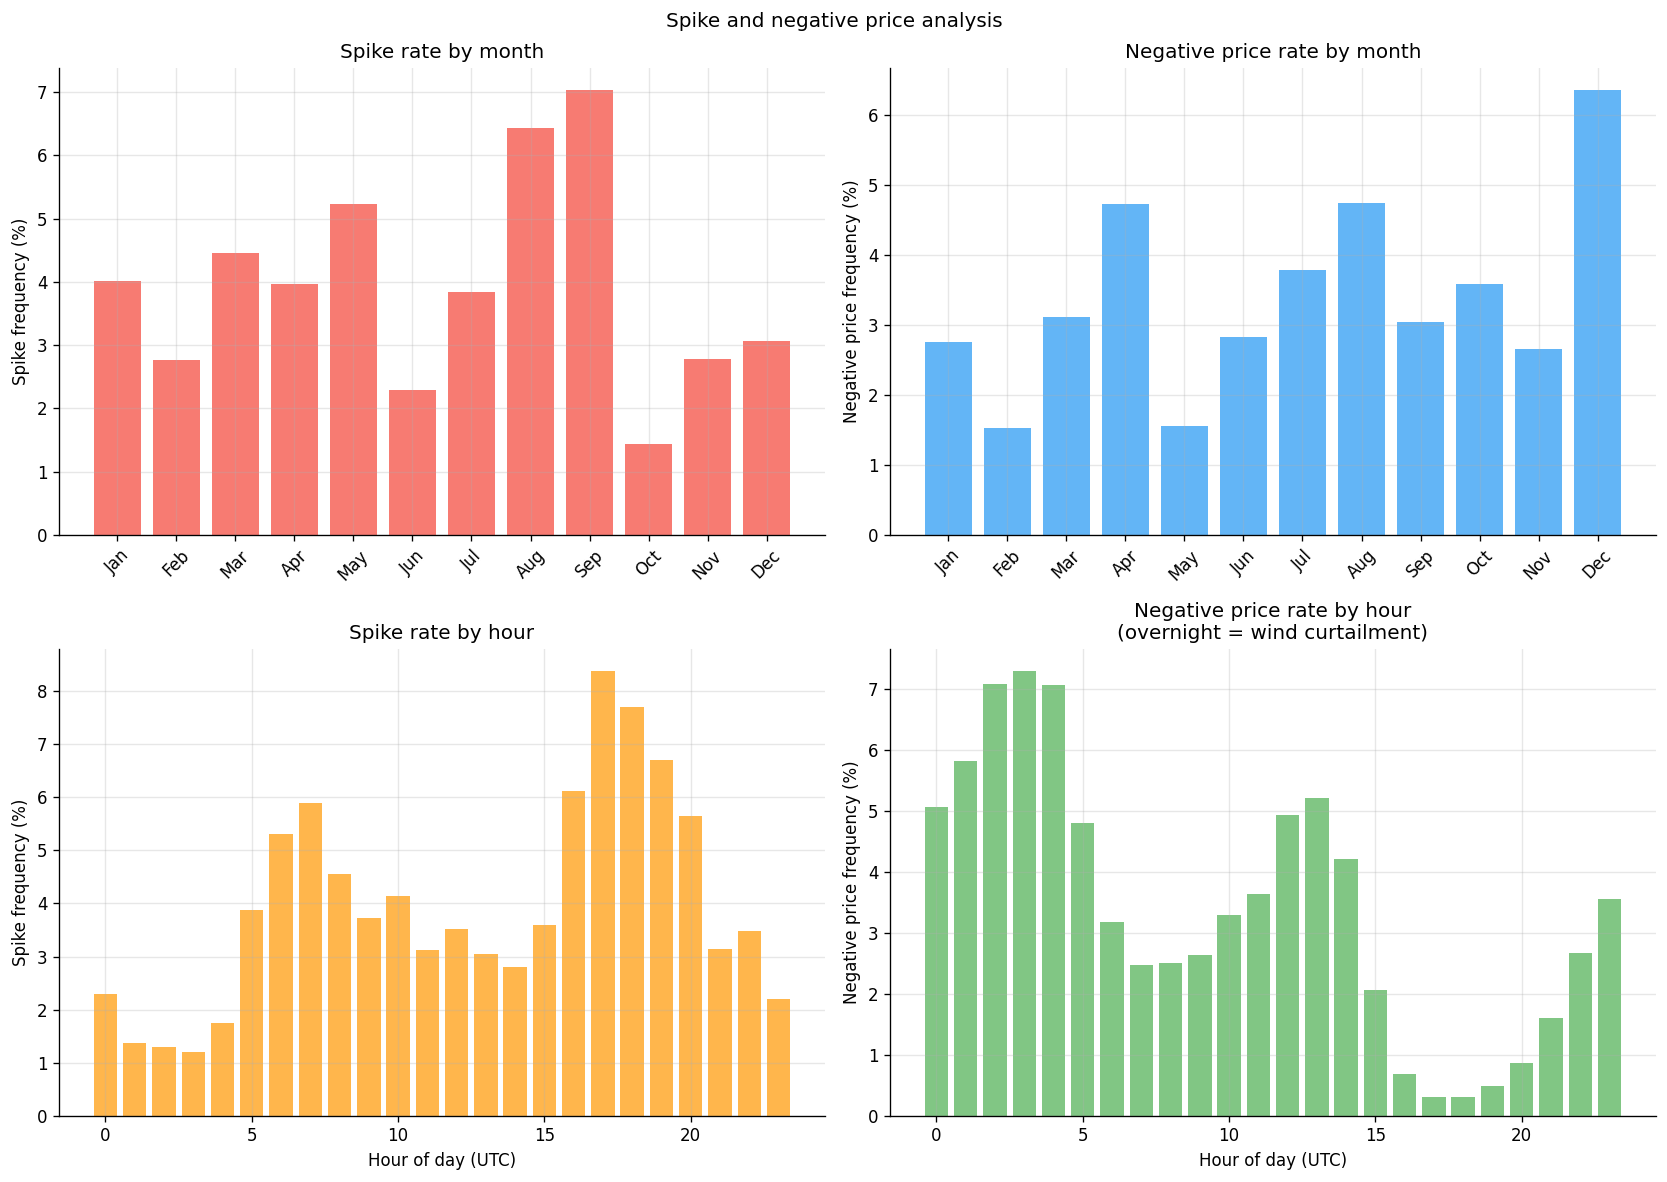

In [ ]:
# ── Plot 4: Spike and negative price seasonality ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Spike and negative price analysis", fontsize=12)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# Top left: spike rate by month
ax = axes[0, 0]
spike_by_month = prices_pd.groupby("month")["is_spike"].mean() * 100
ax.bar(spike_by_month.index, spike_by_month.values, color="#F44336", alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.set_ylabel("Spike frequency (%)")
ax.set_title("Spike rate by month")

# Top right: negative price rate by month
ax = axes[0, 1]
neg_by_month = prices_pd.groupby("month")["is_negative"].mean() * 100
ax.bar(neg_by_month.index, neg_by_month.values, color="#2196F3", alpha=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, rotation=45)
ax.set_ylabel("Negative price frequency (%)")
ax.set_title("Negative price rate by month")

# Bottom left: spike rate by hour
ax = axes[1, 0]
spike_by_hour = prices_pd.groupby("hour")["is_spike"].mean() * 100
ax.bar(spike_by_hour.index, spike_by_hour.values, color="#FF9800", alpha=0.7)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Spike frequency (%)")
ax.set_title("Spike rate by hour")

# Bottom right: negative price rate by hour
ax = axes[1, 1]
neg_by_hour = prices_pd.groupby("hour")["is_negative"].mean() * 100
ax.bar(neg_by_hour.index, neg_by_hour.values, color="#4CAF50", alpha=0.7)
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Negative price frequency (%)")
ax.set_title("Negative price rate by hour\n(overnight = wind curtailment)")

plt.tight_layout()
plt.savefig(PLOT_DIR / "02d_spikes.png", bbox_inches="tight")
plt.show()

---
## 5. Wind-price dependence

The joint distribution of (price, wind) is the key multivariate feature
for the energy market. The relationship is:
- **Non-linear**: prices are relatively insensitive to wind at mid-range levels
  but highly sensitive when wind is very high (negative prices) or very low (spikes)
- **Asymmetric**: high wind → moderate negative prices; low wind → extreme positive spikes
- **Regime-dependent**: the relationship changes in winter vs summer

This non-linearity is exactly what the signature cross-terms $S^{(price, wind)}$
capture — a linear correlation coefficient would completely miss it.


In [ ]:
# ── Wind-price joint analysis ─────────────────────────────────────────────────
# Merge price and wind data
wind_price = df.select([
    "start_time", "mid_price", "pct_wind", "month", "hour"
]).drop_nulls()

wp_pd = wind_price.to_pandas()

# Linear correlation (will be low — relationship is nonlinear)
corr = wp_pd[["mid_price", "pct_wind"]].corr().iloc[0, 1]
print(f"Linear correlation (price, wind%): {corr:.3f}")
print(f"(Low correlation does not mean independence — relationship is nonlinear)")

# Bin wind into deciles and compute price statistics per bin
wp_pd["wind_decile"] = pd.qcut(wp_pd["pct_wind"], q=10, labels=False)
wind_bins = wp_pd.groupby("wind_decile")["mid_price"].agg(["mean", "std", "median",
    lambda x: (x < 0).mean() * 100,
    lambda x: (x > 500).mean() * 100
]).round(2)
wind_bins.columns = ["mean", "std", "median", "pct_negative", "pct_spike"]
print("\nPrice statistics by wind decile (0=lowest wind, 9=highest wind):")
print(wind_bins.to_string())

Linear correlation (price, wind%): -0.213
(Low correlation does not mean independence — relationship is nonlinear)

Price statistics by wind decile (0=lowest wind, 9=highest wind):
               mean     std  median  pct_negative  pct_spike
wind_decile                                                 
0            161.89  248.10  113.06          0.03       2.60
1            142.46  135.95  105.91          0.04       1.81
2            138.93  121.12  106.55          0.11       1.70
3            134.55  106.81  105.00          0.42       1.29
4            124.36   92.44  100.00          0.80       0.55
5            117.23   79.15   98.00          0.77       0.12
6            110.43   73.59   95.59          1.52       0.00
7            108.78   81.03   94.25          3.78       0.06
8             96.30   75.37   88.00          6.19       0.03
9             62.67   74.65   50.13         19.56       0.00


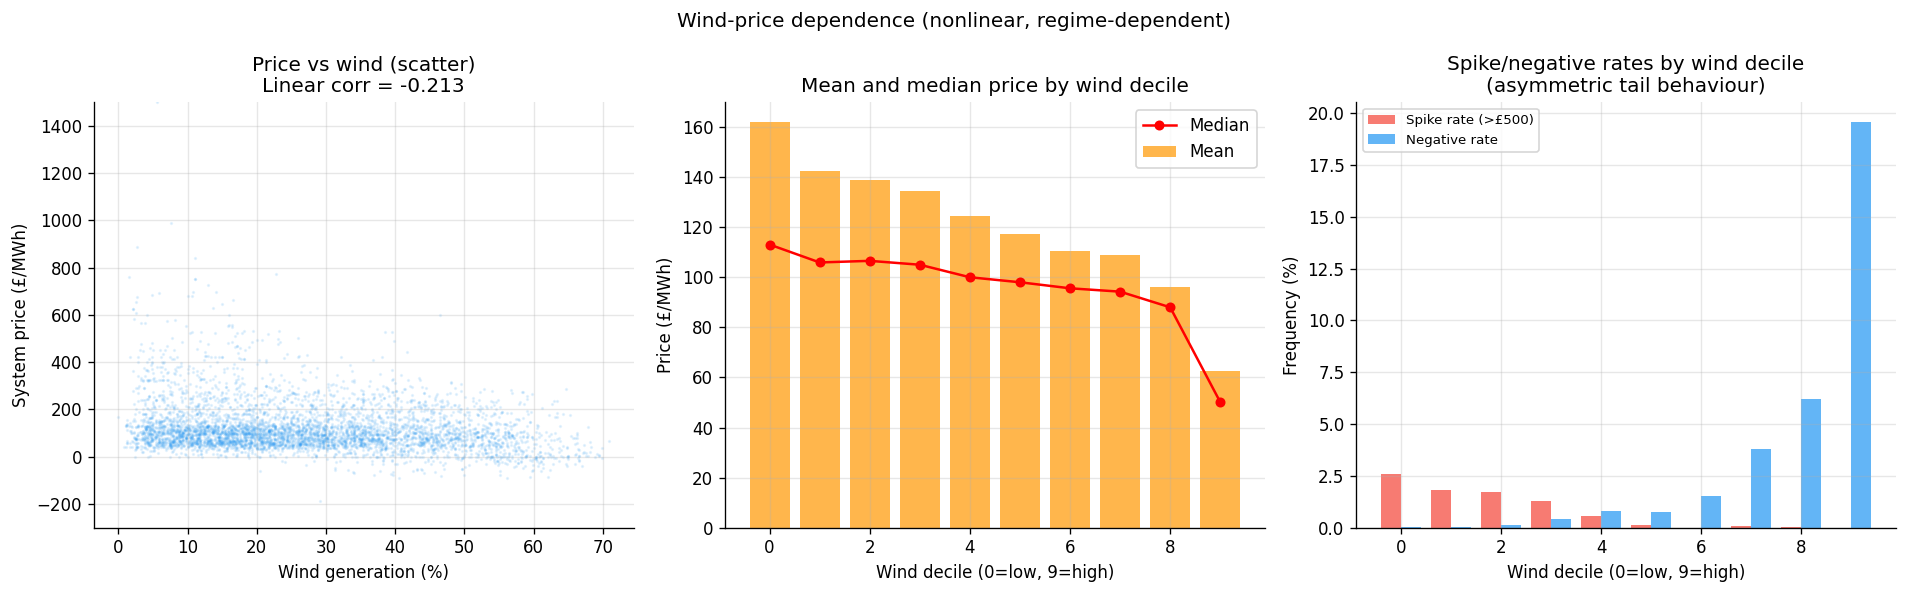

In [ ]:
# ── Plot 5: Wind-price dependence ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Wind-price dependence (nonlinear, regime-dependent)", fontsize=12)

# Left: scatter plot (sample for speed)
ax = axes[0]
sample_idx = np.random.choice(len(wp_pd), size=5000, replace=False)
sample_wp  = wp_pd.iloc[sample_idx]
ax.scatter(sample_wp["pct_wind"], sample_wp["mid_price"],
           alpha=0.1, s=1, color="#2196F3")
ax.set_xlabel("Wind generation (%)")
ax.set_ylabel("System price (£/MWh)")
ax.set_ylim(-300, 1500)
ax.set_title(f"Price vs wind (scatter)\nLinear corr = {corr:.3f}")

# Middle: mean price by wind decile
ax = axes[1]
ax.bar(wind_bins.index, wind_bins["mean"], color="#FF9800", alpha=0.7, label="Mean")
ax.plot(wind_bins.index, wind_bins["median"], "r-o", ms=5, label="Median")
ax.set_xlabel("Wind decile (0=low, 9=high)")
ax.set_ylabel("Price (£/MWh)")
ax.set_title("Mean and median price by wind decile")
ax.legend()

# Right: spike and negative price rate by wind decile
ax = axes[2]
ax.bar(wind_bins.index - 0.2, wind_bins["pct_spike"],
       width=0.4, color="#F44336", alpha=0.7, label="Spike rate (>£500)")
ax.bar(wind_bins.index + 0.2, wind_bins["pct_negative"],
       width=0.4, color="#2196F3", alpha=0.7, label="Negative rate")
ax.set_xlabel("Wind decile (0=low, 9=high)")
ax.set_ylabel("Frequency (%)")
ax.set_title("Spike/negative rates by wind decile\n(asymmetric tail behaviour)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / "02e_wind_price.png", bbox_inches="tight")
plt.show()

---
## 6. Regime labelling — precursor to HMM (Phase 2)

We use a simple rule-based regime labelling here as a Phase 1 placeholder.
In Phase 2 this will be replaced by a properly fitted HMM with Baum-Welch.

**Three regimes**:
- `calm` — price within ±2 std of rolling median, low absolute return
- `volatile` — large absolute return, price within normal range
- `spike` — price exceeds spike threshold or is negative

The regime label is a conditioning variable for the CVAE in notebook 04.


In [ ]:
# ── Rule-based regime labelling ───────────────────────────────────────────────
import pandas as pd

prices_full = df.select(["start_time", "mid_price", "returns"]).to_pandas()
prices_full = prices_full.dropna(subset=["mid_price"]).sort_values("start_time").reset_index(drop=True)

# Rolling statistics
prices_full["roll_med"] = prices_full["mid_price"].rolling(48, min_periods=24, center=True).median()
prices_full["roll_std"] = prices_full["mid_price"].rolling(48, min_periods=24, center=True).std()
prices_full["abs_ret"]  = prices_full["returns"].abs()
prices_full["roll_abs_ret_75"] = prices_full["abs_ret"].rolling(48, min_periods=24).quantile(0.75)

def label_regime(row):
    if pd.isna(row["roll_med"]) or pd.isna(row["roll_std"]):
        return "calm"
    if row["mid_price"] > SPIKE_THRESHOLD_ABS or row["mid_price"] < -50:
        return "spike"
    if not pd.isna(row["abs_ret"]) and not pd.isna(row["roll_abs_ret_75"]):
        if row["abs_ret"] > 3 * row["roll_abs_ret_75"]:
            return "volatile"
    return "calm"

prices_full["regime"] = prices_full.apply(label_regime, axis=1)

regime_counts = prices_full["regime"].value_counts()
print("Regime distribution:")
for regime, count in regime_counts.items():
    print(f"  {regime:10s}: {count:6,}  ({count/len(prices_full)*100:.1f}%)")

Regime distribution:
  calm      : 65,302  (93.1%)
  volatile  :  3,831  (5.5%)
  spike     :    984  (1.4%)


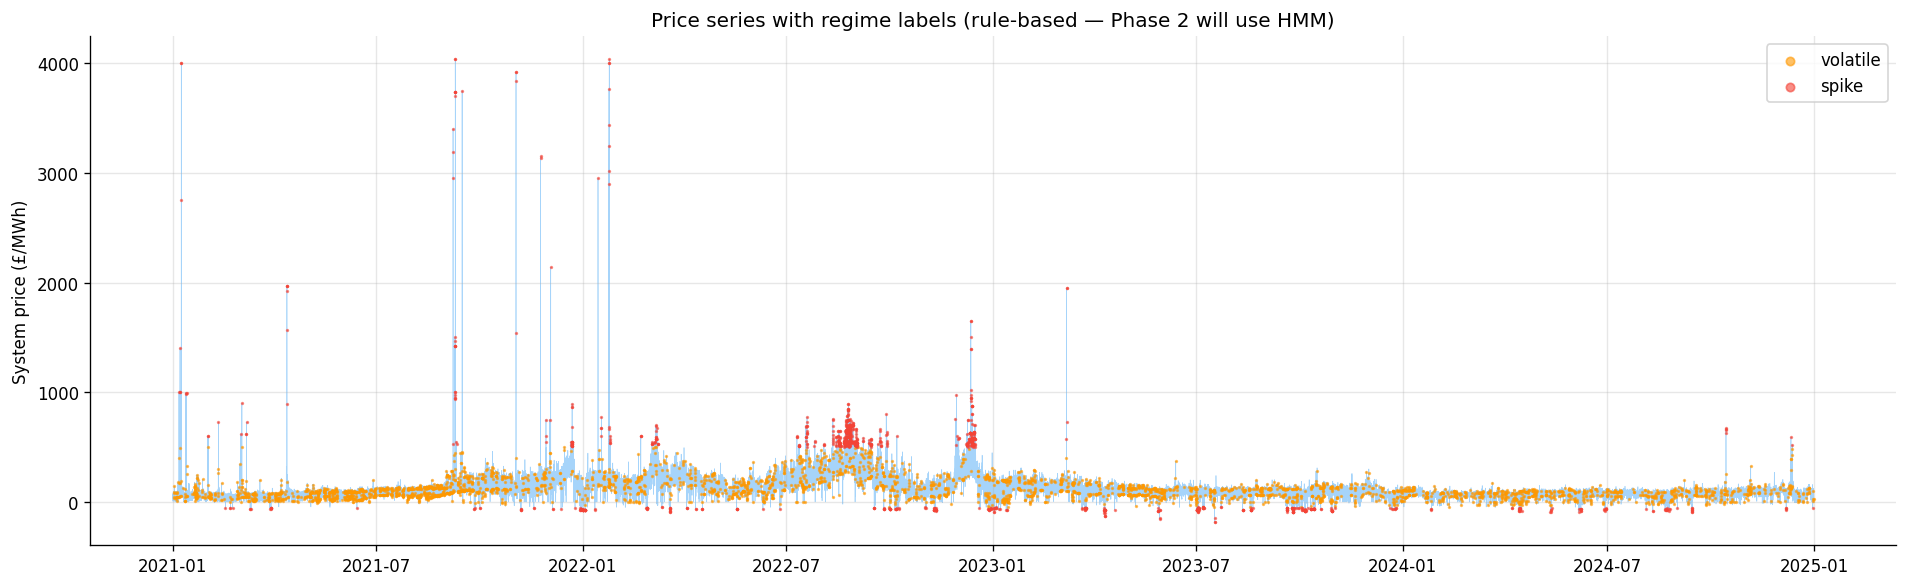

In [ ]:
# ── Plot 6: Regime overlay ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Plot price
ax.plot(prices_full["start_time"], prices_full["mid_price"],
        lw=0.4, color="#90CAF9", alpha=0.8, zorder=1)

# Overlay regime colours
colors = {"calm": None, "volatile": "#FF9800", "spike": "#F44336"}
for regime, color in colors.items():
    if color is None:
        continue
    mask = prices_full["regime"] == regime
    ax.scatter(prices_full.loc[mask, "start_time"],
               prices_full.loc[mask, "mid_price"],
               s=1, c=color, alpha=0.6, label=regime, zorder=2)

ax.set_ylabel("System price (£/MWh)")
ax.set_title("Price series with regime labels (rule-based — Phase 2 will use HMM)")
ax.legend(markerscale=5)
plt.tight_layout()
plt.savefig(PLOT_DIR / "02f_regimes.png", bbox_inches="tight")
plt.show()

---
## 7. Stylized facts summary table

This summary table is the validation checklist for notebook 05.
Each row is a statistic that the generated paths must match.


In [ ]:
# ── Build stylized facts summary ──────────────────────────────────────────────
facts = {
    "n_periods":              len(prices_full),
    "mean_price":             float(np.nanmean(prices)),
    "std_price":              float(np.nanstd(prices)),
    "mean_return":            float(np.nanmean(returns_np)),
    "std_return":             float(np.nanstd(returns_np)),
    "skewness_return":        float(stats.skew(returns_np)),
    "kurtosis_return":        float(stats.kurtosis(returns_np)),
    "pct_negative":           float((prices < 0).mean()),
    "pct_spike_500":          float((prices > 500).mean()),
    "pct_spike_1000":         float((prices > 1000).mean()),
    "acf_abs_ret_lag1":       float(acf_abs_returns[1]),
    "acf_abs_ret_lag48":      float(acf_abs_returns[48]),
    "median_spike_duration":  float(spike_durations.median()),
    "median_neg_duration":    float(neg_durations.median()),
    "wind_price_linear_corr": float(corr),
    "regime_pct_calm":        float((prices_full["regime"] == "calm").mean()),
    "regime_pct_volatile":    float((prices_full["regime"] == "volatile").mean()),
    "regime_pct_spike":       float((prices_full["regime"] == "spike").mean()),
}

facts_df = pl.DataFrame({
    "statistic": list(facts.keys()),
    "value":     [float(v) for v in facts.values()]
})

print("Stylized facts summary (validation targets for notebook 05):")
print(facts_df.to_pandas().to_string(index=False))

Stylized facts summary (validation targets for notebook 05):
             statistic        value
             n_periods 70117.000000
            mean_price   119.732711
             std_price   122.084466
           mean_return    -0.005252
            std_return    85.081158
       skewness_return     0.863344
       kurtosis_return   792.045787
          pct_negative     0.034033
         pct_spike_500     0.007931
        pct_spike_1000     0.000713
      acf_abs_ret_lag1     0.386260
     acf_abs_ret_lag48     0.049980
 median_spike_duration     2.000000
   median_neg_duration     2.000000
wind_price_linear_corr    -0.212874
       regime_pct_calm     0.931329
   regime_pct_volatile     0.054637
      regime_pct_spike     0.014034


In [ ]:
# ── Save outputs ───────────────────────────────────────────────────────────────

# 1. Stylized facts table
facts_df.write_parquet(DATA_DIR / "stylized_facts.parquet")
print(f"Saved: stylized_facts.parquet")

# 2. Returns with regime labels — input to notebook 03 (signatures)
returns_df = pl.from_pandas(
    prices_full[["start_time", "mid_price", "returns", "regime"]].dropna()
)
returns_df.write_parquet(DATA_DIR / "returns.parquet")
print(f"Saved: returns.parquet  ({len(returns_df):,} rows)")

print("\nAll data files:")
for f in sorted(DATA_DIR.glob("*.parquet")):
    print(f"  {f.name}: {f.stat().st_size/1e3:.1f} KB")

Saved: stylized_facts.parquet
Saved: returns.parquet  (70,109 rows)

All data files:
  carbon_intensity.parquet: 2350.3 KB
  elexon_generation.parquet: 3507.9 KB
  elexon_system_prices.parquet: 5590.7 KB
  master.parquet: 10158.7 KB
  returns.parquet: 873.3 KB
  stylized_facts.parquet: 1.3 KB


---
## Summary

Key findings from this EDA:

| Property | Value | Implication for generative model |
|----------|-------|----------------------------------|
| Excess kurtosis | ~800 | Must reproduce heavy tails — Gaussian models fail completely |
| Negative prices | ~3.4% | Cannot use log-price — model must work on raw price path |
| ACF of \|returns\| lag 1 | >0 | Volatility clustering — depth-2 signature terms must be non-trivial |
| Spike duration | ~1–2 periods | Generated spikes must be short-lived, not persistent |
| Wind-price correlation | low (linear) | Linear correlation misses the dependence — need signature cross-terms |
| Three regimes | calm / volatile / spike | CVAE conditioning on regime label improves generation quality |

**Next**: `03_signature_features.ipynb` — apply the lead-lag transform and
compute log-signatures from the price paths, with detailed financial
interpretation of each signature entry.
